In [1]:
from Data_query.trino_config import *
import numpy as np
from visualisation import *
import pytz

In [36]:
stop_trino()

Trino service stopping triggered.


In [16]:
big_workers = 0
workers = 1
num_workers = max(workers, big_workers)
ensure_trino_running(worker_desired_count = workers, big_worker_desired_count=big_workers)
sleep(30)

Trino service is not running. Starting the service...
Trino service triggered.
Service trino-service is now stable.


In [3]:
iceberg_sql("""
         select distinct site_id, state, ac_capacity_kw, export_limit_kw, min_time, max_time, distance_km
         from meta_up23c 
         where avg_pf > .99 and ac_capacity_kw >= 30 and min_time < timestamp '2024-05-01 00:00:00'
""")

,site_id,state,ac_capacity_kw,export_limit_kw,min_time,max_time,distance_km
0,575069184,VIC,50.00,NaN,2024-02-13 14:35:00,2025-06-30 23:55:00,0.555000
1,1817973063,VIC,30.00,NaN,2024-01-01 00:00:00,2025-06-30 23:55:00,0.000000
2,2124568132,NT,91.26,NaN,2024-01-01 00:00:00,2024-08-30 05:25:00,1.110000
3,1970459077,NSW,110.00,NaN,2024-01-01 00:00:00,2025-06-30 23:55:00,1.110000
4,226692893,NT,110.00,0.0,2024-02-05 10:00:00,2025-06-30 23:55:00,1.110000
...,...,...,...,...,...,...,...
485,1094309136,VIC,110.00,NaN,2024-01-19 02:10:00,2025-06-30 23:55:00,1.569777
486,1102691809,NSW,110.00,NaN,2024-01-01 00:00:00,2025-06-30 23:55:00,0.555000
487,958001556,VIC,110.00,NaN,2024-01-01 00:00:00,2024-03-29 23:45:00,0.555000
488,1553939611,VIC,110.00,NaN,2024-01-01 00:00:00,2025-06-30 23:55:00,1.110000


In [17]:
## count the number of timestamps per site when voltvar is not required with GHI > 0
def run_func(args):
  year, month = args
  df = iceberg_sql(f"""with data as (select site_id, t_stamp,  n_lat, n_long
                  from ts inner join meta_up23c as m on ts.circuit_id = m.circuit_id
                  where year = {year} and month = {month} and ts.is_pv=True
                  group by t_stamp,  site_id, n_lat, n_long
                  having avg(voltage) <= 240 and avg(voltage) >= 220),
                  bom10min as (select distinct time, b.latitude, b.longitude, surface_global_irradiance as GHI
                  from bom_nci.solar as b
                  inner join meta_up23c as m on b.latitude = m.n_lat and b.longitude = m.n_long
                  where year={year} and month={month} ),

                    bom5min as ((select time as time_5min, latitude, longitude, GHI
                  from bom10min) union all
                  (select date_add('minute', 5, time) as time_5min, latitude, longitude,
                  GHI
                  FROM bom10min
                    ORDER BY time_5min)),
                  mix_data as (
                  select  d.*, GHI
                  from data as d left join bom5min as b on 
                  d.n_lat = b.latitude and d.n_long = b.longitude and d.t_stamp = b.time_5min)
                  select site_id, count(t_stamp) as num_data, 
                  approx_percentile(GHI, 0.01) as GHI_p1, 
                  approx_percentile(GHI, 0.5) as GHI_p50, 
                  approx_percentile(GHI, 0.99) as GHI_p99 
                  from mix_data 
                  where GHI > 0
                  group by site_id
                  order by num_data
                
  """)
  sleep(10)
  print(f"Completed year={year}, month={month}")
  return df
tasks = [(year, month) for year in (2024, ) for month in range(1, 13) ] 
df_vlim = trino_parallel(run_func, tasks, num_workers=num_workers)

Completed year=2024, month=1
Completed year=2024, month=2
Completed year=2024, month=7
Completed year=2024, month=6
Completed year=2024, month=4
Completed year=2024, month=8
Completed year=2024, month=5
Completed year=2024, month=3
Completed year=2024, month=9
Completed year=2024, month=11
Completed year=2024, month=12
Completed year=2024, month=10


In [18]:
## count the number of timestamps per site when for all voltage range with GHI > 0
def run_func(args):
  year, month = args
  df = iceberg_sql(f"""with data as (select site_id, t_stamp,  n_lat, n_long
                  from ts inner join meta_up23c as m on ts.circuit_id = m.circuit_id
                  where year = {year} and month = {month} and ts.is_pv=True
                  group by t_stamp,  site_id, n_lat, n_long),
                  bom10min as (select distinct time, b.latitude, b.longitude, surface_global_irradiance as GHI
                  from bom_nci.solar as b
                  inner join meta_up23c as m on b.latitude = m.n_lat and b.longitude = m.n_long
                  where year={year} and month={month} ),

                    bom5min as ((select time as time_5min, latitude, longitude, GHI
                  from bom10min) union all
                  (select date_add('minute', 5, time) as time_5min, latitude, longitude,
                  GHI
                  FROM bom10min
                    ORDER BY time_5min)),
                  mix_data as (
                  select  d.*, GHI
                  from data as d left join bom5min as b on 
                  d.n_lat = b.latitude and d.n_long = b.longitude and d.t_stamp = b.time_5min)
                  select site_id, count(t_stamp) as num_data, 
                  approx_percentile(GHI, 0.01) as GHI_p1, 
                  approx_percentile(GHI, 0.5) as GHI_p50, 
                  approx_percentile(GHI, 0.99) as GHI_p99 
                  from mix_data 
                  where GHI > 0
                  group by site_id
                  order by num_data
                
  """)
  sleep(10)
  print(f"Completed year={year}, month={month}")
  return df
tasks = [(year, month) for year in (2024, ) for month in range(1, 13) ] 
df_vall = trino_parallel(run_func, tasks, num_workers=num_workers)

Completed year=2024, month=5
Completed year=2024, month=3
Completed year=2024, month=7
Completed year=2024, month=2
Completed year=2024, month=1
Completed year=2024, month=6
Completed year=2024, month=8
Completed year=2024, month=4
Completed year=2024, month=9
Completed year=2024, month=11
Completed year=2024, month=10
Completed year=2024, month=12


In [22]:
df1 = df_vlim.merge(df_vall, on='site_id', suffixes=('_vlim', '_vall'))

In [33]:
df1.query("num_data_vlim < 100 and num_data_vall > 500")['site_id'].nunique()

5661

In [ ]:
site_id = 2124568132
year, month = 2024, 5
df = iceberg_sql(f"""with data as (select site_id, t_stamp,  sum(cast(power*circuit_polarity as decimal(38, 6)))/1000 as P_kw, 
                 sum(cast(energy_reactive*circuit_polarity as decimal(38, 6)))/1000*12 as Q_kvar, n_lat, n_long
                 from ts inner join meta_up23c as m on ts.circuit_id = m.circuit_id
                 where site_id = {site_id} and year = {year} and month = {month} and ts.is_pv=True
                 group by t_stamp,  site_id, n_lat, n_long),

                 bom10min as (select distinct time, b.latitude, b.longitude, surface_global_irradiance as GHI, cloud_type
                 from bom_nci.solar as b
                 inner join meta_up23c as m on b.latitude = m.n_lat and b.longitude = m.n_long
                 where year={year} and month={month} and site_id = {site_id}),

                  bom5min as ((select time as time_5min, latitude, longitude, GHI, cloud_type
                 from bom10min) union all
                 (select date_add('minute', 5, time) as time_5min, latitude, longitude,
                 GHI, cloud_type
                 FROM bom10min
                  ORDER BY time_5min)),
                  clear_sky as (select date_trunc('day', time + interval '10' hour) AS day
                  from bom10min
                  group by date_trunc('day', time + interval '10' hour)
                  having sum(cloud_type) = 0
                  )

                 select  d.*, GHI, cloud_type
                 from data as d left join bom5min as b on 
                 d.n_lat = b.latitude and d.n_long = b.longitude and d.t_stamp = b.time_5min
                 where date_trunc('day', t_stamp + interval '10' hour)  in (select day from clear_sky)
                 order by t_stamp
               
""")

df['t_stamp'] = pd.to_datetime(df['t_stamp']).dt.tz_localize('utc').dt.tz_convert(pytz.FixedOffset(10*60))
df['GHI'] = df['GHI'].fillna(-1)
df['cloud_type'] = df['cloud_type'].fillna(-1)
df[:2]

,site_id,t_stamp,P_kw,Q_kvar,n_lat,n_long,GHI,cloud_type
0,2124568132,2024-05-04 00:00:00+10:00,0.001883,1.737924,-12.42,130.84,-1.0,-1.0
1,2124568132,2024-05-04 00:05:00+10:00,0.001790,1.739328,-12.42,130.84,-1.0,-1.0


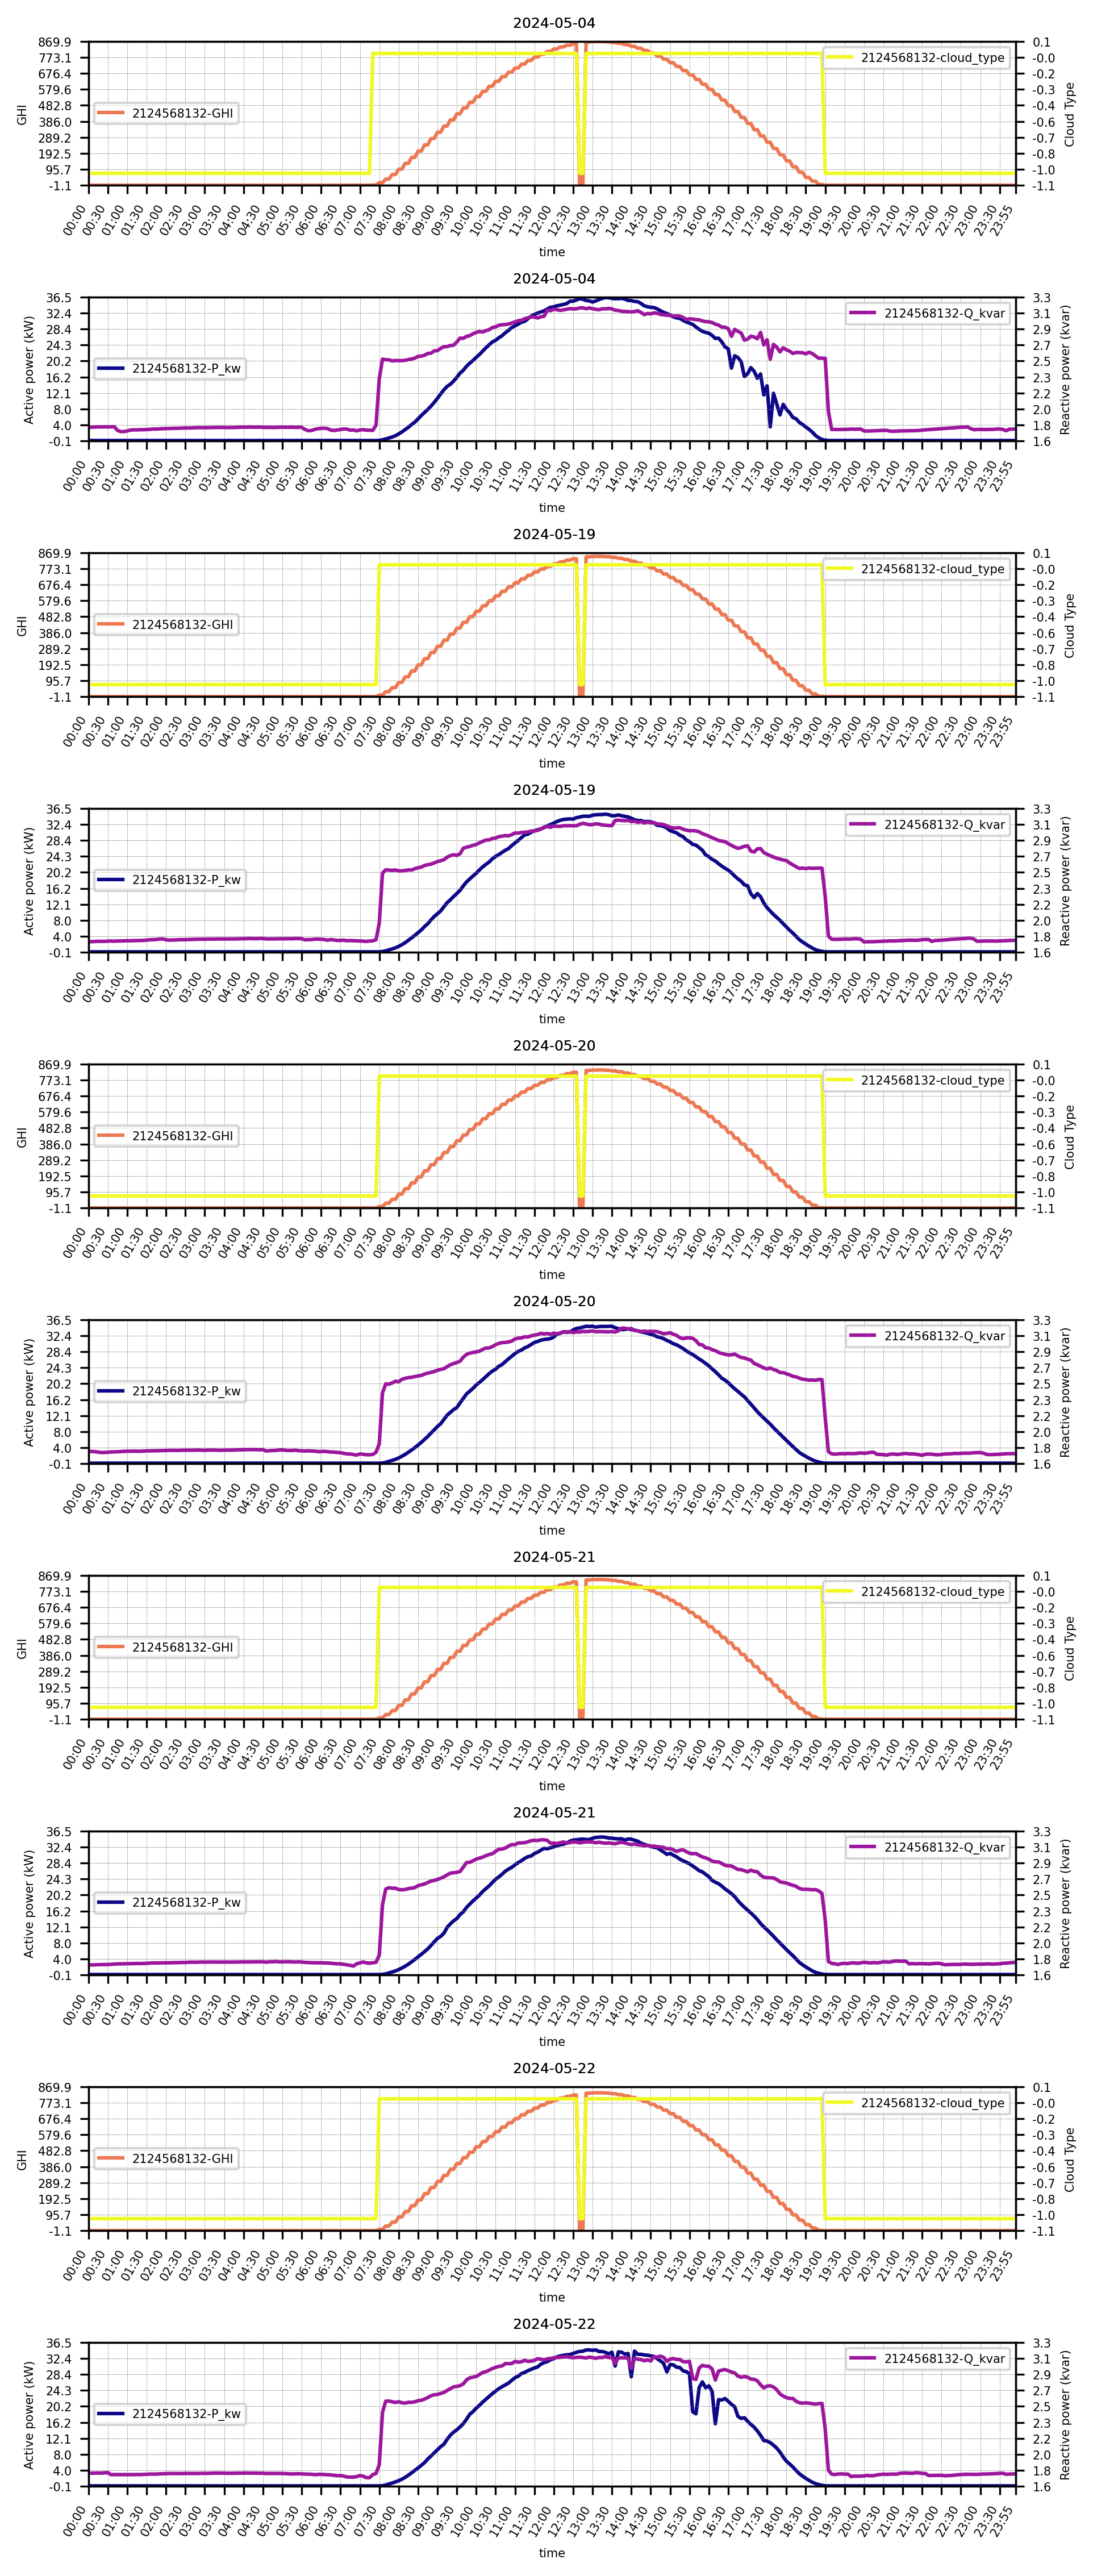

In [35]:
start_time = '2024-05-1 00:00:00+10:00'	 # In sydney local time
end_time =   '2024-06-1 00:00:00+10:00'	 # In sydney local time


num_ticks = 24*2+1
save_as = ''
x_label = 'time'
y_labels = ['Active power (kW)', 'Reactive power (kvar)', 'GHI', 'Cloud Type']
plt_config = {'P_kw': [1, 0, '-', None, None], 'Q_kvar': [1, 1, '-', None, None], 'GHI': [0, 0, '-', None, None], 'cloud_type': [0, 1, '-', None, None]}

color_nights=False
# color_by = 'group'
color_by = 'attribute'
ax_digit = '1.1f'
a=my_plot4(start_time, end_time, df, plt_config=plt_config, ax_digit= ax_digit,
          group_attr='site_id', time_attr='t_stamp', color_nights=color_nights,cmap='plasma',
          figsize=[16/2.54,1.5],  same_scale=1, fontsize=5, fontname='DejaVu Sans', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']], 
          num_ticks=num_ticks, num_yticks=10, dpi=300,  x_format= '%H:%M', 
           legend_loc=['center left', 'upper right'], x_label=x_label, y_labels=y_labels, color_by=color_by,
plot_period=np.timedelta64(1, 'D'), save_as=save_as, rotation = 60, step=0, gridwidth=[0.2, .2], legend_join='-', title='', 
legend_i=0, title_i=0, only1title=0, onlyntime=0)
a.do()

In [23]:
hive_sql("""
         select distinct s.site_id, s.latitude, s.longitude
         from 
         sites as s 
""")

,site_id,latitude,longitude
0,1944472430,-34.470,150.85
1,1492891952,-23.400,150.50
2,1780063290,-12.465,131.00
3,302260061,-27.630,153.30
4,1955208720,-23.715,133.85
...,...,...,...
37618,572834115,-33.840,150.85
37619,662608029,-28.530,153.55
37620,620406052,-21.150,149.05
37621,1722930229,-37.800,145.00
